# **Car Performance**







In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('cars.csv')
df.head()

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,Origin Model
0,Chevrolet Chevelle Malibu,18.0,8,307.0,130,3504,12.0,70,US,US 70
1,Buick Skylark 320,15.0,8,350.0,165,3693,11.5,70,US,US 70
2,Plymouth Satellite,18.0,8,318.0,150,3436,11.0,70,US,US 70
3,AMC Rebel SST,16.0,8,304.0,150,3433,12.0,70,US,US 70
4,Ford Torino,17.0,8,302.0,140,3449,10.5,70,US,US 70


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car           406 non-null    object 
 1   MPG           406 non-null    float64
 2   Cylinders     406 non-null    int64  
 3   Displacement  406 non-null    float64
 4   Horsepower    406 non-null    int64  
 5   Weight        406 non-null    int64  
 6   Acceleration  406 non-null    float64
 7   Model         406 non-null    int64  
 8   Origin        406 non-null    object 
 9   Origin Model  406 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 31.8+ KB


In [ ]:
df.isnull().sum()

,0
Car,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,0
Weight,0
Acceleration,0
Model,0
Origin,0
Origin Model,0


In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns
columns_with_zeros = []

for col in numerical_columns:
    if (df[col] == 0).any():
        columns_with_zeros.append(col)

if columns_with_zeros:
    print(f"Columns with zero values: {columns_with_zeros}")
else:
    print("No numerical columns contain zero values.")

Columns with zero values: ['MPG', 'Horsepower']


In [ ]:
(df['MPG'] == 0).sum()

np.int64(8)

In [ ]:
mpg_zero_rows = df[df['MPG'] == 0]
display(mpg_zero_rows)

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,Origin Model
10,Citroen DS-21 Pallas,0.0,4,133.0,115,3090,17.5,70,Europe,Europe 70
11,Chevrolet Chevelle Concours (sw),0.0,8,350.0,165,4142,11.5,70,US,US 70
12,Ford Torino (sw),0.0,8,351.0,153,4034,11.0,70,US,US 70
13,Plymouth Satellite (sw),0.0,8,383.0,175,4166,10.5,70,US,US 70
14,AMC Rebel SST (sw),0.0,8,360.0,175,3850,11.0,70,US,US 70
17,Ford Mustang Boss 302,0.0,8,302.0,140,3353,8.0,70,US,US 70
39,Volkswagen Super Beetle 117,0.0,4,97.0,48,1978,20.0,71,Europe,Europe 71
367,Saab 900s,0.0,4,121.0,110,2800,15.4,81,Europe,Europe 81


In [ ]:
car_model_mpg_zero = mpg_zero_rows[['Car', 'Model']]
display(car_model_mpg_zero)

,Car,Model
10,Citroen DS-21 Pallas,70
11,Chevrolet Chevelle Concours (sw),70
12,Ford Torino (sw),70
13,Plymouth Satellite (sw),70
14,AMC Rebel SST (sw),70
17,Ford Mustang Boss 302,70
39,Volkswagen Super Beetle 117,71
367,Saab 900s,81


In [ ]:
mpg_updates = {
    'Citroen DS-21 Pallas': 11,
    'Chevrolet Chevelle Concours (sw)': 13,
    'Ford Torino (sw)': 12,
    'Plymouth Satellite (sw)': 13,
    'AMC Rebel SST (sw)': 14,
    'Ford Mustang Boss 302': 13,
    'Volkswagen Super Beetle 117': 26,
    'Saab 900s': 23
}
for car, mpg_value in mpg_updates.items():
    df.loc[df['Car'] == car, 'MPG'] = mpg_value

print("MPG values updated successfully.")

# Verify that the 'MPG' values are no longer zero for these cars
updated_mpg_zero_rows = df[df['Car'].isin(mpg_updates.keys())]
display(updated_mpg_zero_rows[['Car', 'MPG']])

# Display the updated DataFrame
display(df.head())

MPG values updated successfully.


,Car,MPG
10,Citroen DS-21 Pallas,11.0
11,Chevrolet Chevelle Concours (sw),13.0
12,Ford Torino (sw),12.0
13,Plymouth Satellite (sw),13.0
14,AMC Rebel SST (sw),14.0
17,Ford Mustang Boss 302,13.0
39,Volkswagen Super Beetle 117,26.0
80,Chevrolet Chevelle Concours (sw),13.0
367,Saab 900s,23.0


,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,Origin Model
0,Chevrolet Chevelle Malibu,18.0,8,307.0,130,3504,12.0,70,US,US 70
1,Buick Skylark 320,15.0,8,350.0,165,3693,11.5,70,US,US 70
2,Plymouth Satellite,18.0,8,318.0,150,3436,11.0,70,US,US 70
3,AMC Rebel SST,16.0,8,304.0,150,3433,12.0,70,US,US 70
4,Ford Torino,17.0,8,302.0,140,3449,10.5,70,US,US 70


In [ ]:
(df['Horsepower'] == 0).sum()

np.int64(6)

In [ ]:
horsepower_zero_rows = df[df['Horsepower'] == 0]
display(horsepower_zero_rows)

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,Origin Model
38,Ford Pinto,25.0,4,98.0,0,2046,19.0,71,US,US 71
133,Ford Maverick,21.0,6,200.0,0,2875,17.0,74,US,US 74
337,Renault Lecar Deluxe,40.9,4,85.0,0,1835,17.3,80,Europe,Europe 80
343,Ford Mustang Cobra,23.6,4,140.0,0,2905,14.3,80,US,US 80
361,Renault 18i,34.5,4,100.0,0,2320,15.8,81,Europe,Europe 81
382,AMC Concord DL,23.0,4,151.0,0,3035,20.5,82,US,US 82


In [ ]:
car_model_horsepower_zero = horsepower_zero_rows[['Car', 'Model']]
display(car_model_horsepower_zero)

,Car,Model
38,Ford Pinto,71
133,Ford Maverick,74
337,Renault Lecar Deluxe,80
343,Ford Mustang Cobra,80
361,Renault 18i,81
382,AMC Concord DL,82


In [ ]:
horsepower_updates = {
    'Ford Pinto': 75,
    'Ford Maverick': 84,
    'Renault Lecar Deluxe': 51,
    'Ford Mustang Cobra': 118,
    'Renault 18i': 81,
    'AMC Concord DL': 82
}

for car, hp in horsepower_updates.items():
    df.loc[df['Car'] == car, 'Horsepower'] = hp

# Verify updates
df[df['Car'].isin(horsepower_updates.keys())]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,Origin Model
23,Ford Maverick,21.0,6,200.0,84,2587,16.0,70,US,US 70
38,Ford Pinto,25.0,4,98.0,75,2046,19.0,71,US,US 71
107,Ford Maverick,18.0,6,250.0,84,3021,16.5,73,US,US 73
119,Ford Pinto,19.0,4,122.0,75,2310,18.5,73,US,US 73
133,Ford Maverick,21.0,6,200.0,84,2875,17.0,74,US,US 74
137,Ford Pinto,26.0,4,122.0,75,2451,16.5,74,US,US 74
162,Ford Maverick,15.0,6,250.0,84,3158,19.5,75,US,US 75
175,Ford Pinto,23.0,4,140.0,75,2639,17.0,75,US,US 75
181,Ford Pinto,18.0,6,171.0,75,2984,14.5,75,US,US 75
200,Ford Maverick,24.0,6,200.0,84,3012,17.6,76,US,US 76


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.corr(numeric_only=True)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model
MPG,1.000000,-0.773327,-0.802571,-0.778320,-0.831185,0.432164,0.588706
Cylinders,-0.773327,1.000000,0.951787,0.842425,0.895220,-0.522452,-0.360762
Displacement,-0.802571,0.951787,1.000000,0.898047,0.932475,-0.557984,-0.381714
Horsepower,-0.778320,0.842425,0.898047,1.000000,0.866778,-0.696384,-0.420289
Weight,-0.831185,0.895220,0.932475,0.866778,1.000000,-0.430086,-0.315389
Acceleration,0.432164,-0.522452,-0.557984,-0.696384,-0.430086,1.000000,0.301992
Model,0.588706,-0.360762,-0.381714,-0.420289,-0.315389,0.301992,1.000000


weight has the strongest effect on decreasing the MPG

Cars with Weight less than 2000:


,Car,Weight
61,Datsun 1200,1613
151,Toyota Corolla,1649
350,Toyota Starlet,1755
352,Honda Civic 1300,1760
60,Toyota Corolla 1200,1773



Cars with Weight more than 4500:


,Car,Weight
51,Pontiac Safari (sw),5140
110,Chevrolet Impala,4997
49,Dodge Monaco (sw),4955
97,Mercury Marquis Brougham,4952
102,Buick Electra 225 Custom,4951


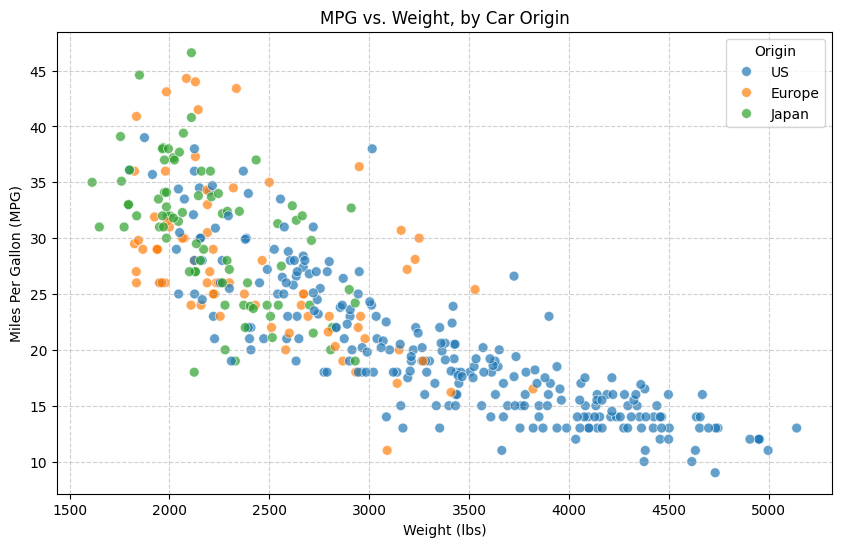

In [ ]:
# Q1 How does weight affect MPG?
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weight', y='MPG', data=df, hue='Origin', s=50, alpha=0.7)
plt.title('MPG vs. Weight, by Car Origin')
plt.xlabel('Weight (lbs)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Extreme weight categories support the observed negative correlation between weight and MPG, where lighter cars consistently show better fuel efficiency than heavier vehicles, with US cars being heavier and Japanese cars being lighter.

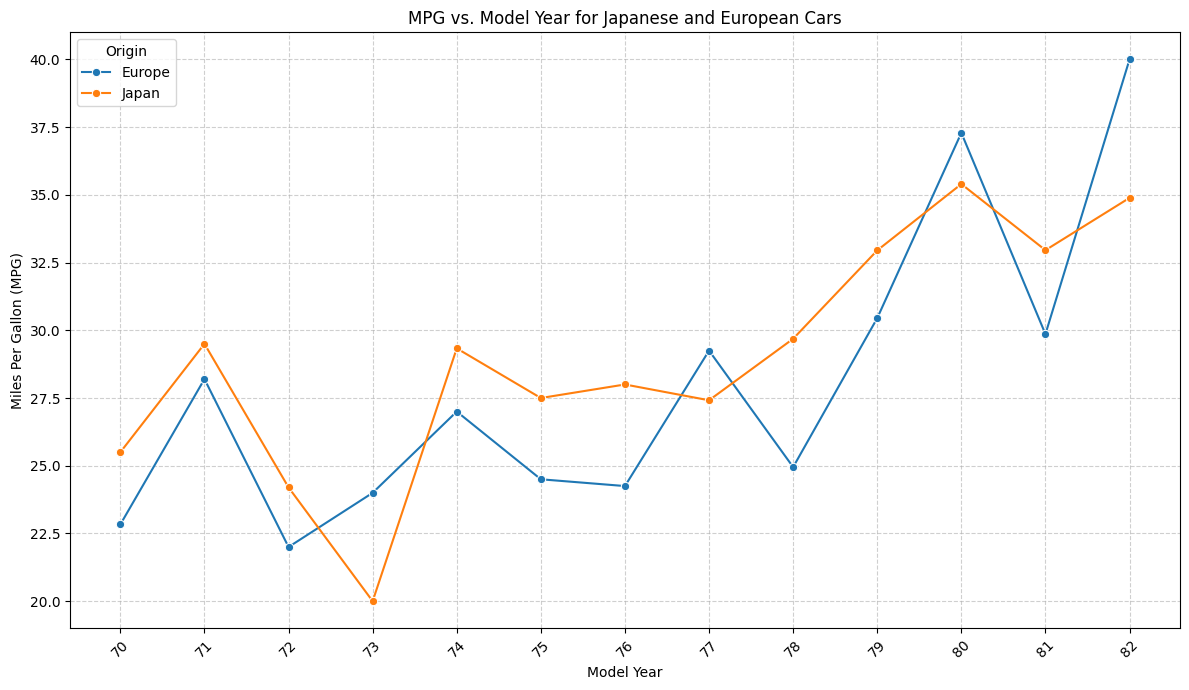

In [ ]:
df_filtered = df[df['Origin'].isin(['Japan', 'Europe'])]

plt.figure(figsize=(12, 7))
sns.lineplot(x='Model', y='MPG', hue='Origin', data=df_filtered, marker='o', errorbar=None)
plt.title('MPG vs. Model Year for Japanese and European Cars')
plt.xlabel('Model Year')
plt.ylabel('Miles Per Gallon (MPG)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df_filtered['Model'].unique(), rotation=45)
plt.tight_layout()
plt.show()

MPG improves with newer car models overall with Japenese Cars improving consistently over the years but European cars ultimatly surpassing the Japanese cars with highest MPG in 80' 82'

## Top 5 Fuel-Efficient European Cars (1980-1982)

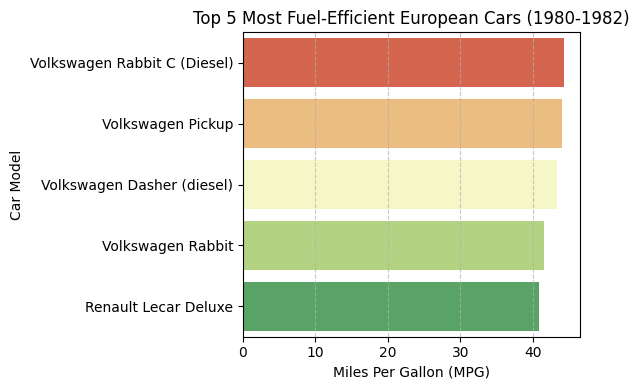

In [ ]:
# Filter for European cars from 1980 to 1982
european_cars_80_82 = df[(df['Origin'] == 'Europe') & (df['Model'].isin([80, 81, 82]))]

# Sort by MPG in descending order and get the top 5
top_5_european_80_82 = european_cars_80_82.nlargest(5, 'MPG')

# Sort in descending order for plotting (best on top)
sorted_top_5_european_80_82 = top_5_european_80_82.sort_values(by='MPG', ascending=False)

plt.figure(figsize=(6, 4)) # Changed from (12, 8) to (6, 4)
sns.barplot(x='MPG', y='Car', hue='Car', data=sorted_top_5_european_80_82, palette='RdYlGn', legend=False)
plt.title('Top 5 Most Fuel-Efficient European Cars (1980-1982)')
plt.xlabel('Miles Per Gallon (MPG)')
plt.ylabel('Car Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()